# Conditional Neural Processes (CNP).
[Conditional Neural Processes](https://arxiv.org/pdf/1807.01613.pdf) (CNPs) were
introduced as a continuation of
[Generative Query Networks](https://deepmind.com/blog/neural-scene-representation-and-rendering/)
(GQN) to extend its training regime to tasks beyond scene rendering, e.g. to
regression and classification.

In [3]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from resolve.utilities import utilities as utils
from resolve.hierarchically_conditioned_attentive_neural_process import DataGeneration
from resolve.hierarchically_conditioned_attentive_neural_process import HCContextAttnNP
from resolve.hierarchically_conditioned_attentive_neural_process import HCTargetAttnLNP
from resolve.hierarchically_conditioned_attentive_neural_process import Trainer
from resolve.hierarchically_conditioned_attentive_neural_process.losses import AsymmetricFocalWithFPPenalty
from torch.utils.tensorboard import SummaryWriter
import yaml
import json


In [5]:
# Set the path to the yaml settings file here
path_to_settings = "../"
with open(f"{path_to_settings}/settings.yaml", "r") as f:
    config_file = yaml.safe_load(f)

torch.manual_seed(0)
BATCH_SIZE = config_file["cnp_settings"]["batch_size_train"]

FILES_PER_BATCH = config_file["cnp_settings"]["files_per_batch_train"]
target_range = config_file["simulation_settings"]["target_range"]
is_binary = target_range[0] >= 0 and target_range[1] <= 1
version = config_file["path_settings"]["version"]
path_out = f'{config_file["path_settings"]["path_out_hcanp"]}/{version}'

In [6]:
x_size, y_size = utils.get_feature_and_label_size(config_file)

In [8]:
d_theta = 4
d_phi = 24
d_y = 1
d_model = 128
model_context = HCContextAttnNP(d_theta, d_phi, d_y, d_model)
model_target = HCTargetAttnLNP(d_theta, d_phi, d_y, d_model)

In [9]:
# load data:
dataset_train_1 = DataGeneration(mode = "training_phase1", 
                                config_file=config_file, 
                                path_to_files=config_file["path_settings"]["path_to_files_train"],
                                batch_size=BATCH_SIZE,
                                files_per_batch=FILES_PER_BATCH
                                )
dataset_train_1.set_feature_stats()

# Save back to the file
with open(f"{path_to_settings}/settings.yaml", "w") as f:
    yaml.safe_dump(config_file, f, sort_keys=False)

dataset_val = DataGeneration(mode = "validation", 
                                config_file=config_file, 
                                path_to_files=config_file["path_settings"]["path_to_files_train"],
                                batch_size=BATCH_SIZE,
                                files_per_batch=FILES_PER_BATCH)

# set the feature mean and std from the training set
if config_file["feature_settings"]["use_normalization"] != False:
    dataset_val.feature_mean = dataset_train_1.feature_mean
    dataset_val.feature_std = dataset_train_1.feature_std


Data Processing in Progress: 100%|██████████| 1000/1000 [00:03<00:00, 306.30it/s]


Overall signal rate in training data: 0.006


Computing global feature stats: 100%|██████████| 1000/1000 [00:05<00:00, 194.28it/s]

Z-score feature mean/std computation completed.


In [10]:
os.system(f'mkdir -p {path_out}/hcanp_{version}_tensorboard_logs')
os.system(f'rm {path_out}/hcanp_{version}_tensorboard_logs/events*')
writer = SummaryWriter(log_dir=f'{path_out}/hcanp_{version}_tensorboard_logs')

In [11]:
model = model_target
optimizer = optim.Adam(model.parameters(), lr=config_file["cnp_settings"]["training"]["phase1"]["learning_rate"])

# Instantiate the training wrapper for the first phase
trainer_1 = Trainer(model, dataset_train_1)

trainer_1.training_epochs = config_file["cnp_settings"]["training"]["phase1"]["training_epochs"]

trainer_1.criterion = AsymmetricFocalWithFPPenalty(
                dataset_train_1.signal_rate if config_file["cnp_settings"]["training"]["phase1"]["loss"]["prior_pos"]==True else 0.5,
                alpha_pos=config_file["cnp_settings"]["training"]["phase1"]["loss"]["alpha_pos"],
                alpha_neg=config_file["cnp_settings"]["training"]["phase1"]["loss"]["alpha_neg"],
                gamma_pos=config_file["cnp_settings"]["training"]["phase1"]["loss"]["gamma_pos"],
                gamma_neg=config_file["cnp_settings"]["training"]["phase1"]["loss"]["gamma_neg"],
                lambda_fp=config_file["cnp_settings"]["training"]["phase1"]["loss"]["lambda_fp"],
                tau_fp=config_file["cnp_settings"]["training"]["phase1"]["loss"]["tau_fp"],
                reduction=config_file["cnp_settings"]["training"]["phase1"]["loss"]["reduction"]
            )

# Train the model
trainer_1.fit(optimizer=optimizer, writer=writer, dataset_val=dataset_val,ckpt_dir=f"{path_out}/checkpoints", ckpt_name=f"cnp_{version}_best.pt",
        monitor="PR-AUC", mode="max",)


Training Epoch 1/2:   0%|          | 0/3000 [00:00<?, ?it/s]

tensor(0.3419, grad_fn=<MeanBackward0>) tensor(-0.0120, grad_fn=<MeanBackward0>) tensor(1.1472, grad_fn=<MeanBackward0>)
tensor(0.4593, grad_fn=<MeanBackward0>)
avg attn to latent token: 0.0029882194940000772


Training Epoch 1/2:   0%|          | 3/3000 [00:09<2:01:09,  2.43s/it]

tensor(0.4188, grad_fn=<MeanBackward0>) tensor(-0.0042, grad_fn=<MeanBackward0>) tensor(0.9789, grad_fn=<MeanBackward0>)
tensor(0.4873, grad_fn=<MeanBackward0>)
avg attn to latent token: 0.0029860257636755705
tensor(0.5074, grad_fn=<MeanBackward0>) tensor(-0.0784, grad_fn=<MeanBackward0>) tensor(0.4778, grad_fn=<MeanBackward0>)
tensor(0.6142, grad_fn=<MeanBackward0>)
avg attn to latent token: 0.002987458137795329
tensor(0.5136, grad_fn=<MeanBackward0>) tensor(-0.0661, grad_fn=<MeanBackward0>) tensor(0.3106, grad_fn=<MeanBackward0>)
tensor(0.4482, grad_fn=<MeanBackward0>)
avg attn to latent token: 0.002973708091303706
tensor(0.5636, grad_fn=<MeanBackward0>) tensor(-0.0938, grad_fn=<MeanBackward0>) tensor(0.4150, grad_fn=<MeanBackward0>)
tensor(0.7056, grad_fn=<MeanBackward0>)


Training Epoch 1/2:   0%|          | 5/3000 [00:09<1:00:56,  1.22s/it]

...

avg attn to latent token: 0.19849319756031036
tensor(1.1318) tensor(0.0472) tensor(0.0008)
tensor(0.4663)
avg attn to latent token: 0.0005214093835093081
tensor(0.9820) tensor(0.0167) tensor(0.0012)
tensor(0.5464)
avg attn to latent token: 0.0013612248003482819
tensor(0.8834) tensor(0.0114) tensor(0.0011)
tensor(0.5154)
avg attn to latent token: 0.1313098818063736


Evaluation: 100%|█████████▉| 998/1000 [01:13<00:00, 17.02it/s]

tensor(0.9190) tensor(-0.0002) tensor(0.0017)
tensor(0.4953)
avg attn to latent token: 0.20146936178207397
tensor(0.9059) tensor(0.0131) tensor(0.0012)
tensor(0.5296)
avg attn to latent token: 0.13269531726837158
tensor(0.9081) tensor(0.0327) tensor(0.0007)
tensor(0.4899)
avg attn to latent token: 0.18724428117275238
tensor(0.9255) tensor(-0.0088) tensor(0.0005)
tensor(0.3677)
avg attn to latent token: 0.20428577065467834
tensor(0.8403) tensor(0.0527) tensor(0.0002)
tensor(0.5239)


Evaluation: 100%|██████████| 1000/1000 [01:13<00:00, 13.63it/s]


avg attn to latent token: 0.04681318253278732
[Epoch 2 Summary]
loss (train)   = 0.00325 loss (val)    = 0.00315
PR-AUC (train) = 0.19650 PR-AUC (val) = 0.24989
Saved new best to ../out/hcacnp/v1.3.4/checkpoints/cnp_v1.3.4_best.pt (PR-AUC=0.249892)
Restored best model from ../out/hcacnp/v1.3.4/checkpoints/cnp_v1.3.4_best.pt (PR-AUC=0.249892)


In [12]:
if config_file["cnp_settings"]["training"]["use_staged_training"] == True:
    torch.save(model.state_dict(), f'{path_out}/cnp_{version}_model_phase1.pth')
    dataset_train_2 = DataGeneration(mode = "training_phase2", 
                                    config_file=config_file, 
                                    path_to_files=config_file["path_settings"]["path_to_files_train"],
                                    batch_size=BATCH_SIZE,
                                    files_per_batch=FILES_PER_BATCH
                                    )
    # set the feature mean and std from the training set
    if config_file["feature_settings"]["use_normalization"] != False:
        dataset_train_2.feature_mean = dataset_train_1.feature_mean
        dataset_train_2.feature_std = dataset_train_1.feature_std

    dataset_train_2.set_loader()

    # Instantiate the training wrapper for the second phase
    trainer_2 = Trainer(model, dataset_train_2)
    trainer_2.epoch_start = config_file["cnp_settings"]["training"]["phase1"]["training_epochs"]
    trainer_2.training_epochs = config_file["cnp_settings"]["training"]["phase2"]["training_epochs"]
    trainer_2.weight_fp=config_file["cnp_settings"]["training"]["phase2"]["weight_false_positives"] # add penalty for false positives
    trainer_2.weight_tp=config_file["cnp_settings"]["training"]["phase2"]["weight_true_positives"] # add reward for true positives
    optimizer = optim.Adam(model.parameters(), lr= config_file["cnp_settings"]["training"]["phase2"]["learning_rate"])
    trainer_2.fit(optimizer=optimizer, writer=writer, dataset_val=dataset_val)
else:
    trainer_2 = trainer_1

In [13]:
dataset_test = DataGeneration(mode = "testing", 
                                config_file=config_file, 
                                path_to_files=config_file["path_settings"]["path_to_files_train"],
                                batch_size=BATCH_SIZE,
                                files_per_batch=FILES_PER_BATCH)

# set the feature mean and std from the training set
if config_file["feature_settings"]["use_normalization"] != False:
    dataset_test.feature_mean = dataset_train_1.feature_mean
    dataset_test.feature_std = dataset_train_1.feature_std

y_pred_val,  y_true_val, loss = trainer_2.evaluate(dataset_test)
metrics_test = trainer_2.log_metrics(writer, y_true_val, y_pred_val, loss, 0, trainer_2.is_binary, leg="Testing")



Evaluation:   0%|          | 5/1000 [00:07<18:43,  1.13s/it]  

tensor(0.9833) tensor(0.0126) tensor(0.0007)
tensor(0.3190)
avg attn to latent token: 0.12049884349107742
tensor(0.9018) tensor(0.0063) tensor(0.0011)
tensor(0.3606)
avg attn to latent token: 0.001021545147523284
tensor(0.9275) tensor(-0.0202) tensor(0.0002)
tensor(0.3718)
avg attn to latent token: 0.042438723146915436
tensor(1.0502) tensor(-0.0041) tensor(0.0020)
tensor(0.3548)
avg attn to latent token: 0.1974640041589737
tensor(0.9037) tensor(-0.0197) tensor(0.0012)
tensor(0.3908)
avg attn to latent token: 0.0005322729120962322
tensor(0.8448) tensor(0.0291) tensor(0.0002)
tensor(0.5770)


Evaluation:   1%|          | 9/1000 [00:07<08:40,  1.90it/s]

avg attn to latent token: 0.20483747124671936
tensor(0.9164) tensor(0.0067) tensor(0.0012)
tensor(0.6802)
avg attn to latent token: 0.2913081645965576
tensor(0.9578) tensor(-0.0145) tensor(0.0015)
tensor(0.5323)
avg attn to latent token: 0.15363220870494843
tensor(0.8485) tensor(-0.0121) tensor(0.0012)
tensor(0.4813)
avg attn to latent token: 0.0132130803540349
tensor(0.9248) tensor(-0.0014) tensor(0.0004)
tensor(0.6787)
avg attn to latent token: 0.07972382009029388
tensor(0.9899) tensor(0.0056) tensor(0.0007)
tensor(0.6041)
avg attn to latent token: 0.0006644519744440913
tensor(0.9785) tensor(-0.0295) tensor(0.0017)
tensor(0.4343)
avg attn to latent token: 0.0005742737557739019
tensor(1.0269) tensor(0.0193) tensor(0.0018)
tensor(0.4029)
avg attn to latent token: 0.0005021383985877037


Evaluation:   2%|▏         | 17/1000 [00:07<03:17,  4.98it/s]

...

tensor(0.9063) tensor(-0.0017) tensor(0.0012)
tensor(0.4987)
avg attn to latent token: 0.0006688364665023983
tensor(0.9725) tensor(0.0241) tensor(0.0010)
tensor(0.6167)
avg attn to latent token: 0.02936786413192749
tensor(0.9354) tensor(-0.0220) tensor(0.0011)
tensor(0.4136)
avg attn to latent token: 0.0005329655832611024
tensor(1.0834) tensor(0.0118) tensor(0.0010)
tensor(0.4921)
avg attn to latent token: 0.0005349162966012955
tensor(0.9355) tensor(0.0098) tensor(0.0011)
tensor(0.3002)
avg attn to latent token: 0.19423837959766388
tensor(1.0736) tensor(-0.0364) tensor(0.0022)


Evaluation: 100%|█████████▉| 999/1000 [01:02<00:00, 21.50it/s]

tensor(0.2425)
avg attn to latent token: 0.15490306913852692
tensor(0.9419) tensor(0.0371) tensor(0.0009)
tensor(0.3183)
avg attn to latent token: 0.0020468789152801037
tensor(1.0569) tensor(-0.0424) tensor(0.0020)
tensor(0.3264)
avg attn to latent token: 0.0005855368217453361
tensor(0.9413) tensor(-0.0324) tensor(0.0020)
tensor(0.7555)
avg attn to latent token: 0.001995907397940755
tensor(0.9132) tensor(0.0127) tensor(0.0016)
tensor(0.2748)
avg attn to latent token: 0.20086197555065155
tensor(0.9183) tensor(0.0001) tensor(0.0010)


Evaluation: 100%|██████████| 1000/1000 [01:02<00:00, 16.01it/s]


tensor(0.5249)
avg attn to latent token: 0.19749486446380615


In [14]:
metrics_test

{'Loss': 0.0030998580768355167,
 'MAE': 0.45974066853523254,
 'MSE': 0.3198555111885071,
 'R2': -43.87028884887695,
 'PR-AUC': 0.24205770112513064,
 'Accuracy': 0.55272,
 'Precision': 0.015798970206398803,
 'Recall': 1.0,
 'F1': 0.031106489905554112,
 'ROC_AUC': 0.7747426522431055,
 'Average_Precision': 0.015798970206398803}

In [15]:
writer.close()
torch.save(model.state_dict(), f'{path_out}/cnp_{version}_model.pth')
os.system(f'cp {path_to_settings}/settings.yaml {path_out}/cnp_{version}_settings.yaml')

0

In [16]:
columns = ['iteration','fidelity', 'nsamples'] + config_file["simulation_settings"]["theta_headers"] + ['y_cnp','y_cnp_err','y_raw']
# Define column dtypes to avoid ambiguity
dtypes = (
    [('iteration', float),
     ('fidelity', float),
     ('nsamples', float)] +
    [(name, float) for name in config_file["simulation_settings"]["theta_headers"]] +
    [('y_cnp', float), ('y_cnp_err', float), ('y_raw', float)]
)

df = pd.DataFrame(np.empty((0, len(dtypes)), dtype=dtypes))
df.columns = [name for name, _ in dtypes]  # Set column names
for f,file in enumerate(config_file["path_settings"]["path_to_files_predict"]):
    dataset_predict = DataGeneration(mode = "prediction", 
                                    config_file=config_file, 
                                    path_to_files=file,
                                    batch_size=BATCH_SIZE,
                                    files_per_batch=1)

    # set the feature mean and std from the training set
    if config_file["feature_settings"]["use_normalization"] != False:
        dataset_predict.feature_mean = dataset_train_1.feature_mean
        dataset_predict.feature_std = dataset_train_1.feature_std

    theta, counts, mu_avg_per_theta, sigma_avg_per_theta, y_avg_per_theta = trainer_2.predict(dataset_predict,writer)

    iteration = config_file["path_settings"]["iteration"][f] * np.ones(len(theta)).reshape(-1, 1)
    fidelity = config_file["path_settings"]["fidelity"][f] * np.ones(len(theta)).reshape(-1, 1)

    data_combined = np.concatenate([iteration,fidelity,counts,theta, mu_avg_per_theta, sigma_avg_per_theta, y_avg_per_theta], axis=1)
    df = pd.concat([df, pd.DataFrame(data_combined, columns=columns)], ignore_index=True)

df.to_csv(f'{path_out}/cnp_{version}_output.csv', index=False)

Processing files:   0%|          | 0/200 [00:00<?, ?file/s]

tensor(1.5249) tensor(-0.0412) tensor(0.0125)
tensor(0.5446)
avg attn to latent token: 0.314229816198349


TypeError: Array.resize() got an unexpected keyword argument 'axis'

In [ ]:

def get_marginalized(x_data, y_data, x_min, x_max, keep_axis, grid_steps=500):
        """
        Marginalizes predictions over all but one feature using random sampling when only one 
        prediction is available per sample (y_hf has shape (n_samples, 1)).
        """

        x_keep = x_data[:, keep_axis]

        # Define bins along the kept axis in the original scale.
        bin_edges = np.linspace(x_min, x_max, grid_steps + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

        # For each bin, compute the median and 1σ percentiles (16th and 84th) from the samples in the bin.
        medians = np.empty(grid_steps)
        lower_vals = np.empty(grid_steps)
        upper_vals = np.empty(grid_steps)
        for i in range(grid_steps):
            # Use a half-open interval except for the last bin.
            if i < grid_steps - 1:
                mask = (x_keep >= bin_edges[i]) & (x_keep < bin_edges[i+1])
            else:
                mask = (x_keep >= bin_edges[i]) & (x_keep <= bin_edges[i+1])
            if np.sum(mask) > 0:
                bin_values = y_data[mask]
                medians[i] = np.median(bin_values)
                lower_vals[i] = np.percentile(bin_values, 16)
                upper_vals[i] = np.percentile(bin_values, 84)
            else:
                medians[i] = np.nan
                lower_vals[i] = np.nan
                upper_vals[i] = np.nan

        # Compute errors for plotting (errorbars represent the distance from the median to the percentiles)
        lower_error = medians - lower_vals
        upper_error = upper_vals - medians
        
        return bin_centers, medians, lower_error, upper_error


In [ ]:
import matplotlib.lines as mlines
import pandas as pd
def get_marginialized_all(config_file, grid_steps=100):
        x_labels = config_file["simulation_settings"]["theta_headers"]
        x_labels_plot = config_file["simulation_settings"]["theta_headers_plot"]
        target_headers_plot = config_file["simulation_settings"]["target_headers_plot"]
        x_min = config_file["simulation_settings"]["theta_min"]
        x_max = config_file["simulation_settings"]["theta_max"]
        path_out  = config_file["path_settings"]["path_out_hcanp"]
        version   = config_file["path_settings"]["version"]

        data=pd.read_csv(f'{path_out}/{version}/cnp_{version}_output.csv')
        print(f'{path_out}/{version}/cnp_{version}_output.csv')
        y_label_sim = 'y_raw'
        y_label_cnp = 'y_cnp'
        fidelities  = np.unique(config_file["path_settings"]["fidelity"])
        x_data = []
        y_data = []
        y_sim = []
        y_data_min=1.
        y_data_max=0.
        y_sim_min=1.
        y_sim_max=0.
        for f in fidelities:
                x_data.append(data.loc[(data['fidelity']==f)][x_labels].to_numpy())
                y_data.append(data.loc[(data['fidelity']==f)][y_label_cnp].to_numpy())
                y_sim.append(data.loc[(data['fidelity']==f)][y_label_sim].to_numpy())
                y_data_min=min(y_data_min,np.min(y_data[-1]))
                y_data_max=max(y_data_max,np.max(y_data[-1]))
                y_sim_min=min(y_sim_min,np.min(y_sim[-1]))
                y_sim_max=max(y_sim_max,np.max(y_sim[-1]))


        colors=[["salmon","darkturquoise"],["darkred","teal"],["orangedred","darkslategrey"]]
        colors=[["teal","darkturquoise"],["darkred","teal"],["orangedred","darkslategrey"]]

        markers=['.','s','o''x']
        grid_steps = 100

        n_cols = len(x_labels)
        n_rows = 2

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(10 * n_cols, 5 * n_rows), squeeze=False)

        for i, param in enumerate(x_labels_plot):
                for f in range(len(x_data)):
                        # Get marginalized draws
                        x_cnp, y_cnp, _, _ = get_marginalized(
                        x_data=x_data[f], y_data=y_data[f],
                        x_min=x_min[i], x_max=x_max[i], keep_axis=i, grid_steps=grid_steps
                        )

                        x_raw, y_raw, _, _ = get_marginalized(
                        x_data=x_data[f], y_data=y_sim[f],
                        x_min=x_min[i], x_max=x_max[i], keep_axis=i, grid_steps=grid_steps
                        )

                        # First row: y_cnp
                        ax_cnp = axes[1][i]
                        ax_cnp.scatter(x_cnp, y_cnp, color=colors[f][0], alpha=1., marker=markers[f], s=200)
                        if f == 0:
                                if i == 0: ax_cnp.set_ylabel(target_headers_plot+"$_{CNP}$", fontsize=24)
                                #if i== 0: ax_cnp.set_xscale('log')
                                ax_cnp.set_xlabel(param, fontsize=24)
                                #ax_cnp.tick_params(axis='y', labelcolor=colors[f][0])

                        # Second row: y_raw
                        ax_raw = axes[0][i]
                        ax_raw.scatter(x_raw, y_raw, color=colors[f][1], alpha=1., marker=markers[f], s=200)
                        if f == 0 and i == 0:
                                ax_raw.set_ylabel(target_headers_plot+"$_{raw}$", fontsize=24)
                                #if i== 0: ax_raw.set_xscale('log')
                                #ax_raw.set_xlabel(param, fontsize=16)
                                #ax_raw.tick_params(axis='y', labelcolor=colors[f][1])
                        ax_cnp.tick_params(axis='both', labelsize=14)
                        ax_raw.tick_params(axis='both', labelsize=14)

        # Construct legend
        handles = []
        handles.append(mlines.Line2D([], [], color=colors[0][1], marker=markers[0],markersize=50, linestyle='None', label=f'before CNP'))
        handles.append(mlines.Line2D([], [], color=colors[0][0], marker=markers[0],markersize=50, linestyle='None', label=f'after CNP'))

        fig.legend(
        handles=handles,
        ncol=2 * len(x_data),
        bbox_to_anchor=(0.98, 1.07),
        fontsize=24
        )

        fig.tight_layout(rect=[0, 0.05, 1, 1])  # leave space for the legend


        # Adjust layout
        plt.tight_layout()
        return fig

../out/hcacnp/v1.3.4/cnp_v1.3.4_output.csv


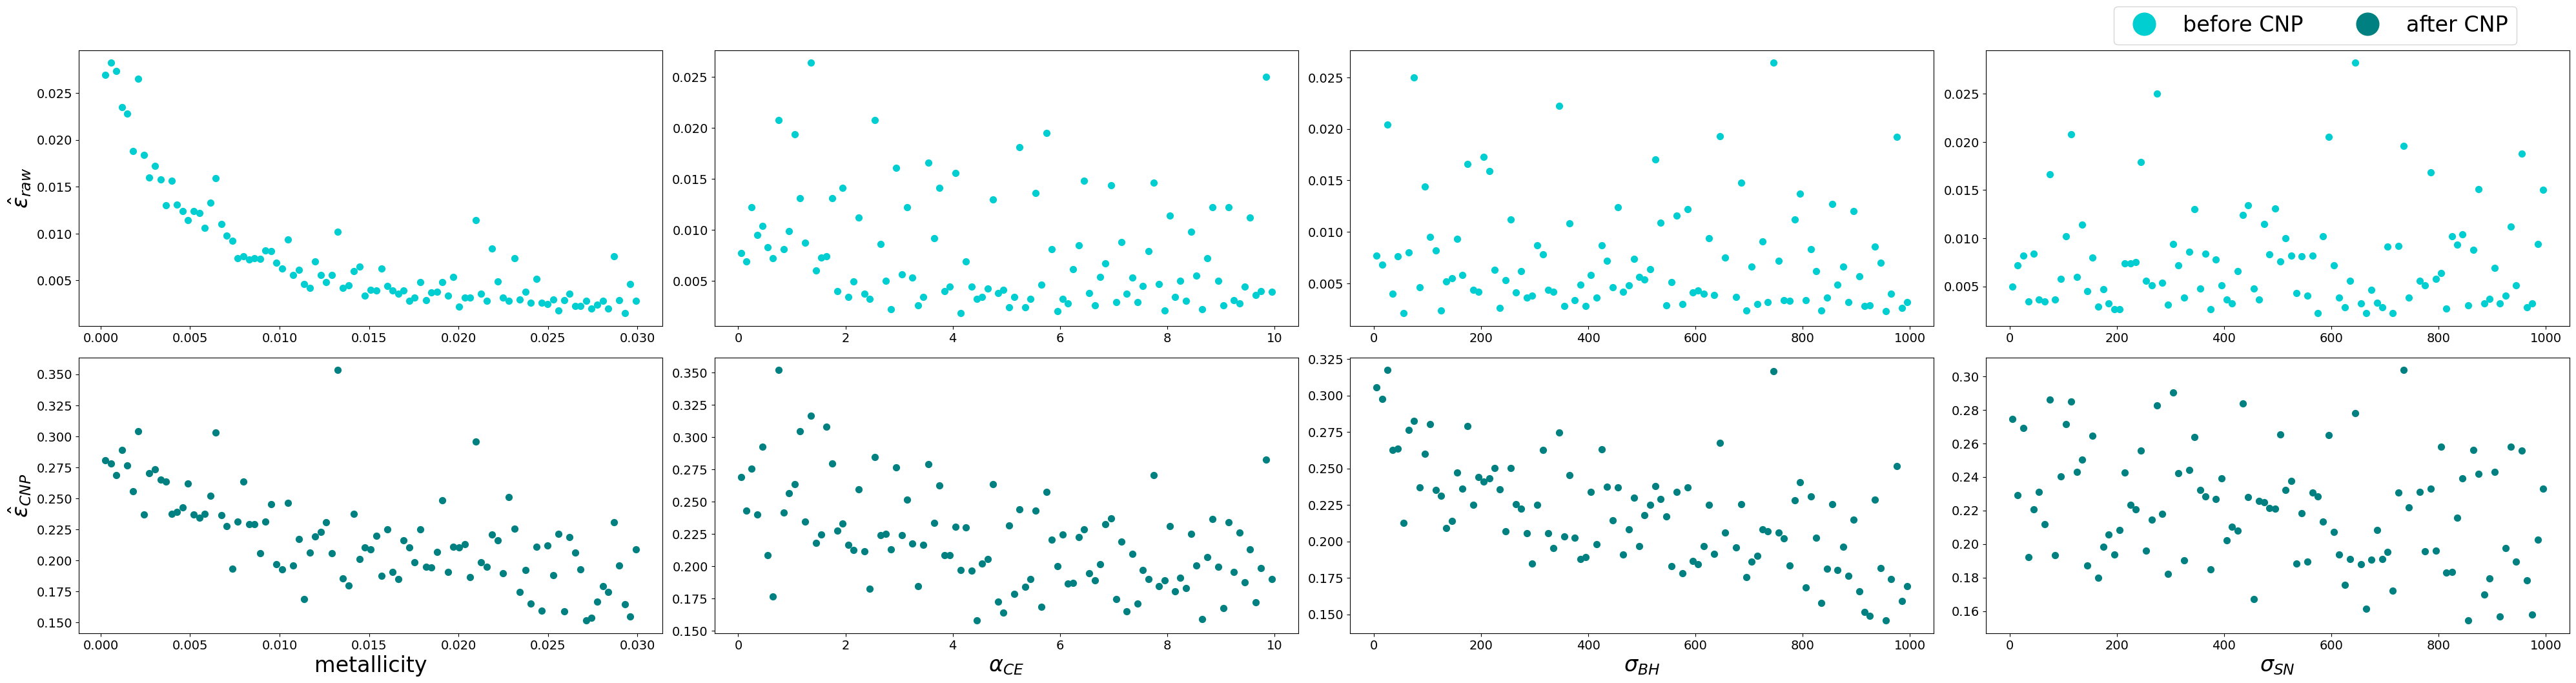

In [ ]:
fig=get_marginialized_all(config_file=config_file)

fig.savefig(f'{path_out}/cnp_{version}_output.png')

In [ ]:
trainer_2.metrics_train

{'Loss': 0.0016010548373354444,
 'MAE': 0.22278587520122528,
 'MSE': 0.15835893154144287,
 'R2': -20.612537384033203,
 'PR-AUC': 0.4234249477289514,
 'Accuracy': 0.7964333333333333,
 'Precision': 0.03498983156906711,
 'Recall': 0.9999096861594039,
 'F1': 0.06761365891790054,
 'ROC_AUC': 0.8974149276036294,
 'Average_Precision': 0.03498733816966297}

In [ ]:
with open(f'{path_out}/cnp_{version}_metrics.json', "w") as f:
    json.dump(trainer_2.metrics_train, f, indent=4)

In [ ]:
0.2*1/1000

0.0002

#  Start TensorBoard

Run this in terminal:

tensorboard --logdir=\<path to tensor board log dir\> --host=0.0.0.0 --port=7007

Open:

http://localhost:7007/